In [108]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [109]:
df = pd.read_csv(r'data/kmeans/Mall_Customers.csv')

In [110]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [111]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [112]:
X = df[["Annual Income (k$)",	"Spending Score (1-100)"]]
X = torch.tensor(X.values, dtype=torch.float32)

In [113]:
X.shape

torch.Size([200, 2])

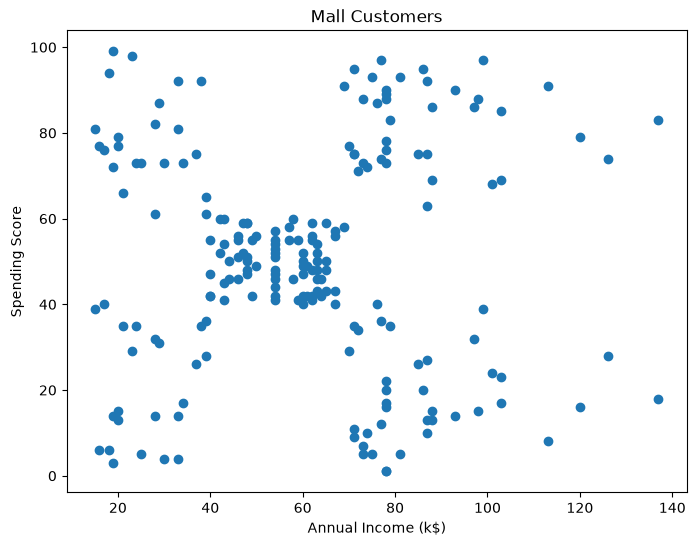

In [114]:
# idk but i am bad at remembering the plotting library codes most of the times
plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1]
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.title("Mall Customers")

plt.show()

In [115]:
# so here even tho we have this as unsupervised, we can viz and human-ly
# find out whether how many centroids(k) should we take.

# but again naive mistake, this is just example data, in reality we know that the data can be
# of many more dims. so if in case this is fixed using PCA or t-SNE.
# will gain more on this soon

# anyways here we can go for k=5 for better acc, and also k=2 if we slice in between. since this data is so less k=2 also seems a fit
# but we going for k=5

In [116]:
def initialize_centroids(X, k):
    indices = torch.randperm(len(X))[:k]
    return X[indices].clone()
centroids = initialize_centroids(X, 5)

print(centroids)
print(centroids.shape)

tensor([[120.,  79.],
        [ 71.,  11.],
        [ 72.,  71.],
        [ 28.,  82.],
        [ 40.,  55.]])
torch.Size([5, 2])


In [117]:
def assign(X, centroids):
    assig = []
    for x in X:
        dist = []
        for c in centroids:
            dist.append(torch.sum((x-c)**2))
        dist = torch.tensor(dist)
        assig.append(torch.argmin(dist))
    return torch.tensor(assig)

tensor([4, 3, 4, 3, 4, 3, 1, 3, 1, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 1, 3,
        4, 3, 4, 4, 4, 3, 1, 3, 1, 3, 1, 3, 1, 3, 4, 3, 4, 3, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 2, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 2, 2, 2, 4, 2, 4, 4, 4, 2, 2, 4, 4, 2, 2, 4, 2, 2, 2,
        2, 1, 2, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
        1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
        1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
        1, 0, 1, 0, 0, 0, 0, 0])
torch.Size([200])


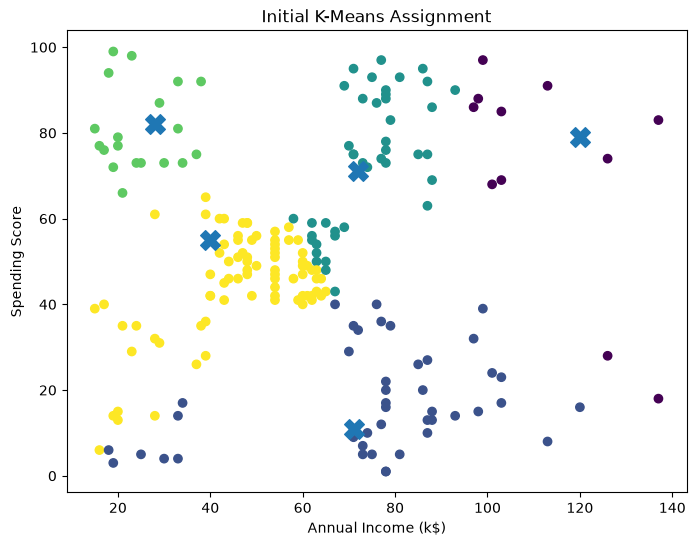

In [118]:
# again fuck plot
assignments = assign(X, centroids)

print(assignments)
print(assignments.shape)

plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=assignments
)

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="X",
    s=200
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.title("Initial K-Means Assignment")

plt.show()

In [131]:
def update_cen(X, assignment, k):
    centroids = []
    for i in range(k):
        pts = []
        for j in range(len(X)):
            if assignment[j] == i:
                pts.append(X[j])
        centroids.append((torch.stack(pts)).mean(dim=0))
    return torch.stack(centroids)

In [132]:
c = initialize_centroids(X, 5)
for i in range(10):
    assignments = assign(X, c)
    new_centroids = update_cen(X, assignments, 5)
    print(f"iter {i + 1}")
    c = new_centroids
c

iter 1
iter 2
iter 3
iter 4
iter 5
iter 6
iter 7
iter 8
iter 9
iter 10


tensor([[25.7273, 79.3636],
        [26.3043, 20.9130],
        [55.2963, 49.5185],
        [86.5385, 82.1282],
        [88.2000, 17.1143]])

In [142]:
# now class
class KMeans:
    def __init__(self, k = 3, max_iter=100, tolerance=1e-4):
        self.k = k
        self.max_iter = max_iter
        self.tolerance = tolerance
    def fit(self, X):
        self.centroids = initialize_centroids(X, self.k)
        for i in range(self.max_iter):
            # assignment
            assig = assign(X, self.centroids)

            # update
            new_cents = update_cen(X, assig, self.k)

            # check
            shift = torch.sum((new_cents - self.centroids)**2)

            self.centroids = new_cents

            if shift < self.tolerance :
                break

        self.labels_ = assig
        self.n_iters_ = i + 1
        return self

    def predict(self, X):
        return assign(X, self.centroids)

In [143]:
kmeans = KMeans(k=5, max_iter = 100)
kmeans.fit(X)

In [144]:
print("Iterations:", kmeans.n_iters_)
print("Centroids:")
print(kmeans.centroids)

Iterations: 6
Centroids:
tensor([[26.3043, 20.9130],
        [86.5385, 82.1282],
        [25.7273, 79.3636],
        [88.2000, 17.1143],
        [55.2963, 49.5185]])


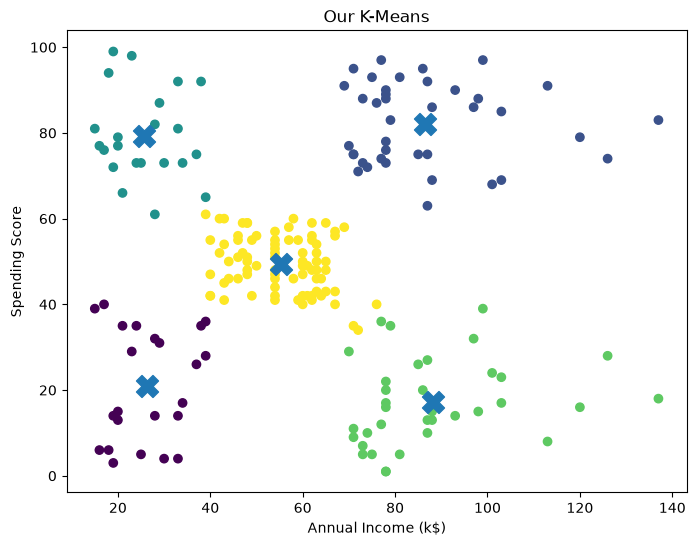

In [146]:
# matplotlibs are all vibe coded of mine
plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=kmeans.labels_
)

plt.scatter(
    kmeans.centroids[:, 0],
    kmeans.centroids[:, 1],
    marker="X",
    s=250
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.title("Our K-Means")

plt.show()

In [150]:
# looks good but k was chosen by us, and it wont make sense to have kmeans along k
# it seems there is something called inertia, and it looks like

$$J = \sum_{i=1}^{N} ||x_i - \mu_{c_i}||^2$$

In [151]:
def inertia(X, assignment, centroids):
    total = 0
    for i in range(len(X)):
        clus = assignment[i]
        dist = torch.sum((X[i] - centroids[clus])**2)
        total += dist
    return total

In [152]:
score = inertia(X, assignments, centroids)
score

tensor(613352.)

In [154]:
k_values = range(1, 11)
inertias = []
for k in k_values:
    kmeans = KMeans(k=k,max_iter=100)
    kmeans.fit(X)
    score = inertia(X, kmeans.labels_, kmeans.centroids)
    inertias.append(score.item())
    print(f"K = {k:2d} , Inertia = {score.item():.2f}")

K =  1 , Inertia = 269981.28
K =  2 , Inertia = 183729.42
K =  3 , Inertia = 132485.38
K =  4 , Inertia = 73679.75
K =  5 , Inertia = 44454.48
K =  6 , Inertia = 42702.12
K =  7 , Inertia = 31605.87
K =  8 , Inertia = 33812.02
K =  9 , Inertia = 29650.59
K = 10 , Inertia = 25798.02


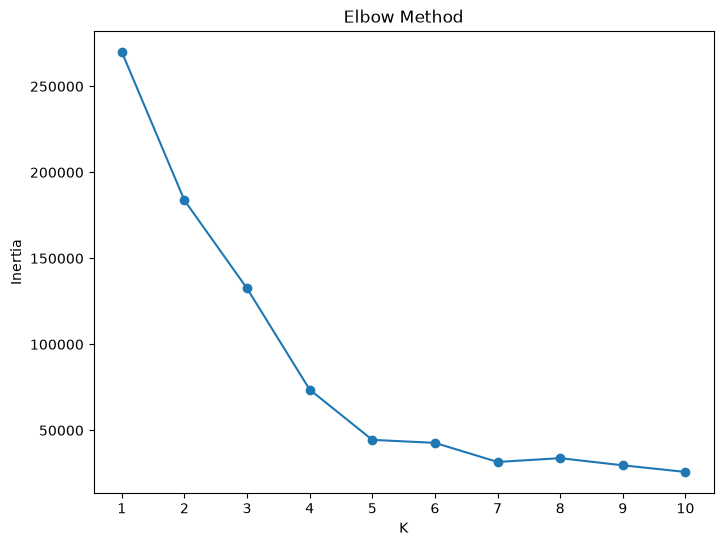

In [155]:
plt.figure(figsize=(8, 6))

plt.plot(
    list(k_values),
    inertias,
    marker="o"
)

plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.xticks(list(k_values))

plt.show()

In [162]:
# this helps us choose a k value, by showing how it effects the data
# as in in the above graph we see for each k how much gain of points are we having,
# but at a certain point its converging (k=5) and after which it stays the same.
# by it stays the same i mean , increasing k doesnt bag more points for the k clusters
# above method is also called elbow method

In [163]:
# but this is not enuf it seems for choosing k.
# there is another intersecting method so we can finally get down to a k value
# it is called silhouette score. higher the better! and this is how it looks,

$$s(i) = \frac{b(i) - a(i)}{\max(\{a(i), b(i)\})}$$

In [164]:
# helps in checking whther are k clusters actually good?
# sees how close a point is to its own cluster and how far it is from other clusters?
# higher = better separation

In [165]:
def silhouette_score(X, assignments):
    scores = []
    for i in range(len(X)):
        current_cluster = assignments[i]
        
        # calc a
        same_cluster_distances = []
        for j in range(len(X)):
            if i == j:
                continue
            if assignments[j] == current_cluster:
                distance = torch.sqrt(torch.sum((X[i] - X[j]) ** 2))
                same_cluster_distances.append(distance)
        a = torch.stack(same_cluster_distances).mean()

        # calc b
        other_cluster_averages = []
        for cluster_id in range(int(assignments.max()) + 1):
            if cluster_id == current_cluster:
                continue
            other_cluster_distances = []
            for j in range(len(X)):
                if assignments[j] == cluster_id:
                    distance = torch.sqrt(torch.sum((X[i] - X[j]) ** 2))
                    other_cluster_distances.append(distance)
            if len(other_cluster_distances) > 0:
                average_distance = torch.stack(other_cluster_distances).mean()
                other_cluster_averages.append(average_distance)
        b = torch.stack(other_cluster_averages).min()

        # silhouette score
        s = (b - a) / max(a, b)
        scores.append(s)
    return torch.stack(scores).mean()

In [166]:
k_values = range(2, 11)

silhouette_scores = []

for k in k_values:
    kmeans = KMeans(k=k, max_iter=100)
    kmeans.fit(X)
    score = silhouette_score(X, kmeans.labels_)
    silhouette_scores.append(score.item())
    print(f"K = {k} , "f"Silhouette = {score.item():.4f}")

K = 2 , Silhouette = 0.2969
K = 3 , Silhouette = 0.4676
K = 4 , Silhouette = 0.4938
K = 5 , Silhouette = 0.5532
K = 6 , Silhouette = 0.4389
K = 7 , Silhouette = 0.4572
K = 8 , Silhouette = 0.4359
K = 9 , Silhouette = 0.4754
K = 10 , Silhouette = 0.4290


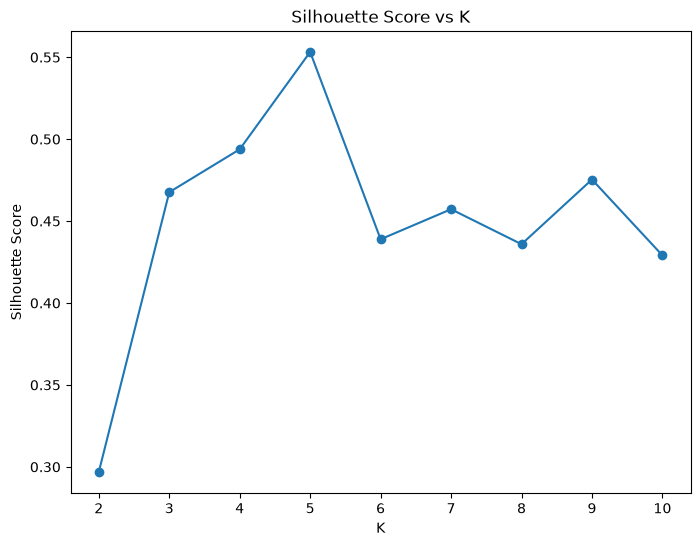

In [167]:
plt.figure(figsize=(8, 6))

plt.plot(
    list(k_values),
    silhouette_scores,
    marker="o"
)

plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")

plt.xticks(list(k_values))

plt.show()

In [168]:
# elbow method says
# "Is adding another cluster worth the extra complexity?"

# silhouette scoring says:
# "Are the clusters actually good?"